# Lab 9 — SVM and PCA

This notebook implements:
- **Part A:** Support Vector Machine (SVM) classification on the UCI Breast Cancer Wisconsin (Diagnostic) dataset.
- **Part B:** Principal Component Analysis (PCA) on the UCI Wine dataset.



## Part A — Support Vector Machine (SVM)

**Aim:** Implement a linear-kernel SVM for binary classification and evaluate its performance.


In [1]:
# Import the libraries required for Part A.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)


### 1. Load the Breast Cancer Wisconsin dataset

The dataset contains measurements computed from digitized images of breast masses. The target is binary: malignant or benign.

In [2]:
# Load the dataset provided by scikit-learn.
# It is the same UCI Breast Cancer Wisconsin (Diagnostic) dataset.
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

print("Dataset shape:", X.shape)
print("Target classes:", cancer.target_names)
X.head()


Dataset shape: (569, 30)
Target classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2. Check and preprocess the data

SVM is sensitive to the scale of features because it uses distances and margins. Therefore, the features are standardized so that each feature has approximately zero mean and unit variance.

The `Pipeline` used below ensures that scaling is learned only from the training data, preventing data leakage.

In [3]:
# Check for missing values.
print("Missing values:", X.isnull().sum().sum())

# Check the class distribution.
print("\nClass distribution:")
print(y.value_counts().rename(index=dict(enumerate(cancer.target_names))))


Missing values: 0

Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64


### 3. Split the dataset into training and testing sets

An 80:20 split is used as required. `stratify=y` keeps approximately the same class proportion in both sets.

In [4]:
# Split the data into 80% training and 20% testing data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 455
Testing samples: 114


### 4. Train a Linear Kernel SVM and tune the hyperparameter

For a linear SVM, `C` controls the trade-off between maximizing the margin and minimizing classification errors. A larger `C` penalizes misclassification more strongly.

GridSearchCV tests several values of `C` using cross-validation and selects the value with the best validation score.

In [5]:
# Build a pipeline: standardization is performed before SVM training.
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])

# Values of C to explore during hyperparameter tuning.
param_grid = {
    "svm__C": [0.01, 0.1, 1, 10, 100]
}

# Perform 5-fold cross-validation to find the best C.
grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    scoring="f1"
)

grid_search.fit(X_train, y_train)

print("Best hyperparameter:", grid_search.best_params_)
print("Best cross-validation F1 score:", grid_search.best_score_)


Best hyperparameter: {'svm__C': 0.1}
Best cross-validation F1 score: 0.9827547753047131


### 5. Evaluate the tuned SVM

The model is evaluated on the test set using accuracy, precision, recall, F1-score, and a confusion matrix.

In [6]:
# Use the best model found by GridSearchCV to make predictions.
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)

# Calculate the required classification metrics.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))


Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861

Classification Report:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



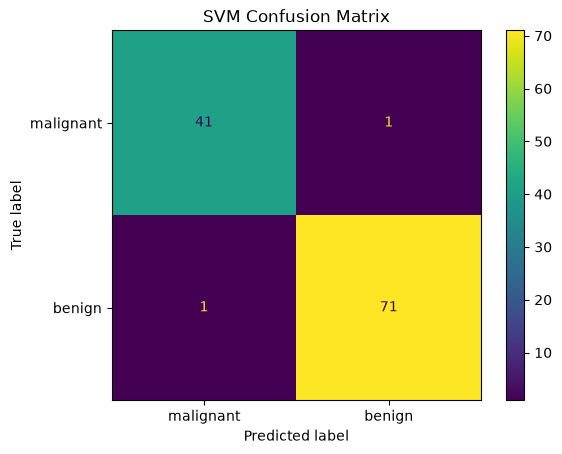

In [7]:
# Display the confusion matrix.
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cancer.target_names
)
disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()


### 6. SVM observations

The linear SVM performs classification by finding a separating hyperplane with a large margin between the two classes. Standardization is important because the original features have different numerical scales. Hyperparameter tuning of `C` helps select an appropriate balance between margin size and classification errors. The final accuracy, precision, recall, and F1-score indicate how effectively the model classifies the two classes on unseen data.

## Part B — Principal Component Analysis (PCA)

**Aim:** Reduce the 13-dimensional Wine dataset to a smaller number of principal components while measuring how much variance is retained.

In [8]:
# Import the libraries required for PCA and LDA.
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


### 1. Load and standardize the Wine dataset

The Wine dataset contains 13 numerical features and three wine classes. Standardization is performed before PCA because PCA is affected by the scale of the input features.

In [9]:
# Load the Wine dataset.
wine = load_wine()

X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="target")

print("Original dataset shape:", X_wine.shape)
print("Number of classes:", len(np.unique(y_wine)))

# Standardize all 13 features.
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

print("Standardized dataset shape:", X_wine_scaled.shape)


Original dataset shape: (178, 13)
Number of classes: 3
Standardized dataset shape: (178, 13)


### 2. Apply PCA: 13 features → 2 principal components

PCA creates new orthogonal features called principal components. The first component captures the maximum possible variance, the second captures the maximum remaining variance subject to being orthogonal to the first, and so on.

In [10]:
# Reduce the standardized dataset from 13 features to 2 principal components.
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_wine_scaled)

print("Transformed dataset shape:", X_pca_2.shape)
print("\nExplained variance ratio:")
for i, ratio in enumerate(pca_2.explained_variance_ratio_, start=1):
    print(f"PC{i}: {ratio:.4f} ({ratio * 100:.2f}%)")


Transformed dataset shape: (178, 2)

Explained variance ratio:
PC1: 0.3620 (36.20%)
PC2: 0.1921 (19.21%)


### 3. Calculate cumulative explained variance

To determine how many components are needed for at least 95% variance retention, PCA is first fitted using all 13 components. The cumulative explained variance is then calculated.

In [11]:
# Fit PCA with all available components so that cumulative variance can be calculated.
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_wine_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Display variance explained by every principal component.
variance_table = pd.DataFrame({
    "Principal Component": np.arange(1, len(explained_variance) + 1),
    "Explained Variance Ratio": explained_variance,
    "Cumulative Explained Variance": cumulative_variance
})

variance_table


,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,1,0.361988,0.361988
1,2,0.192075,0.554063
2,3,0.111236,0.665300
3,4,0.070690,0.735990
4,5,0.065633,0.801623
5,6,0.049358,0.850981
6,7,0.042387,0.893368
7,8,0.026807,0.920175
8,9,0.022222,0.942397
9,10,0.019300,0.961697


In [12]:
# Find the minimum number of components needed to retain at least 95% variance.
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Minimum components required for at least 95% variance:", n_components_95)
print(f"Variance retained: {cumulative_variance[n_components_95 - 1] * 100:.2f}%")


Minimum components required for at least 95% variance: 10
Variance retained: 96.17%


### 4. Plot cumulative explained variance

The plot shows how the retained information increases as more principal components are included.

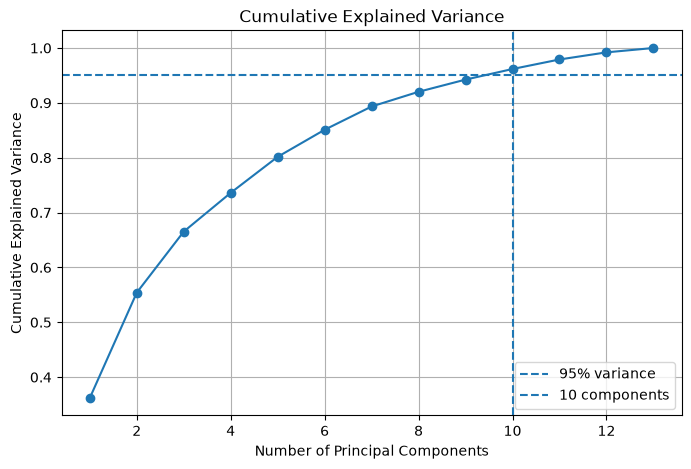

In [13]:
# Plot cumulative explained variance against the number of components.
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.axvline(n_components_95, linestyle="--", label=f"{n_components_95} components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.legend()
plt.show()


### 5. Visualize the two-dimensional PCA representation

Each point represents a wine sample. Different classes are displayed separately so that the class distribution in the transformed feature space can be observed.

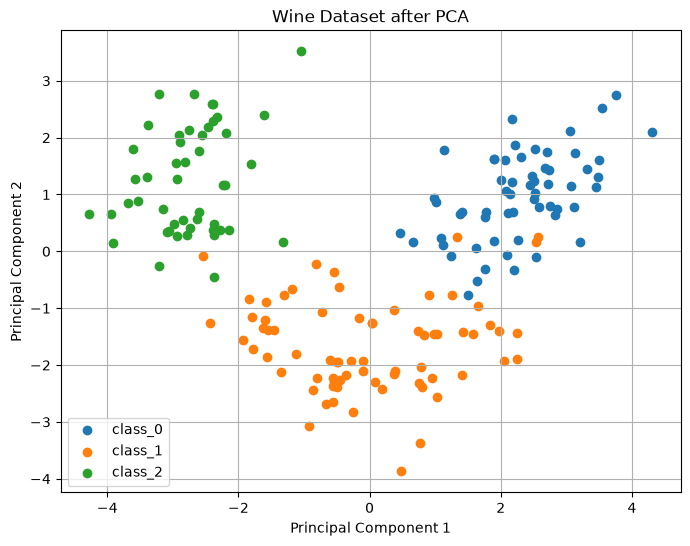

In [14]:
# Plot the first two principal components.
plt.figure(figsize=(8, 6))

for class_value, class_name in enumerate(wine.target_names):
    mask = y_wine == class_value
    plt.scatter(
        X_pca_2[mask, 0],
        X_pca_2[mask, 1],
        label=class_name
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Dataset after PCA")
plt.legend()
plt.grid(True)
plt.show()


### 6. Original vs. transformed dataset

| Aspect | Original Dataset | PCA Dataset |
|---|---|---|
| Number of features | 13 | 2 |
| Representation | Original chemical measurements | Principal components |
| Information | 100% of original variance | Variance retained by PC1 and PC2 |
| Computational cost | Higher | Lower |
| Interpretability | Features have direct meanings | Components are combinations of original features |

Reducing 13 dimensions to 2 makes visualization and many downstream computations simpler, but some information is discarded.

### 7. Interpret the first two principal components

The principal components are linear combinations of the original standardized features. Their coefficients, called loadings, indicate how strongly each original feature contributes to a component. A large absolute loading indicates a stronger contribution.

In [15]:
# Display the feature loadings for PC1 and PC2.
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=wine.feature_names,
    columns=["PC1", "PC2"]
)

print("Feature loadings for the first two principal components:")
loadings


Feature loadings for the first two principal components:


,PC1,PC2
alcohol,0.144329,0.483652
malic_acid,-0.245188,0.224931
ash,-0.002051,0.316069
alcalinity_of_ash,-0.239320,-0.010591
magnesium,0.141992,0.299634
total_phenols,0.394661,0.065040
flavanoids,0.422934,-0.003360
nonflavanoid_phenols,-0.298533,0.028779
proanthocyanins,0.313429,0.039302
color_intensity,-0.088617,0.529996


### 8. Advantages, limitations, and applications of PCA

**Advantages:**
- Reduces dimensionality while retaining the maximum possible variance for a chosen number of components.
- Can reduce computational cost and memory usage.
- Helps visualize high-dimensional datasets in 2D or 3D.
- Can reduce redundancy caused by correlated features.

**Limitations:**
- PCA is unsupervised and does not use class labels.
- Principal components can be difficult to interpret because they combine multiple original features.
- PCA is sensitive to feature scaling, so standardization is often necessary.
- Important information for a particular prediction task may not correspond to the directions of maximum variance.

**Applications:**
- Data visualization
- Noise reduction
- Feature compression
- Exploratory data analysis
- Preprocessing before machine learning models


## Extra Credit — Linear Discriminant Analysis (LDA)

Unlike PCA, LDA is supervised: it uses class labels while finding a lower-dimensional representation. Its objective is to maximize separation between classes while minimizing variation within each class.

The Wine dataset has three classes, so LDA can produce at most `number of classes - 1 = 2` discriminants.

In [16]:
# Apply LDA and reduce the Wine dataset to two linear discriminants.
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

print("LDA transformed dataset shape:", X_lda.shape)


LDA transformed dataset shape: (178, 2)


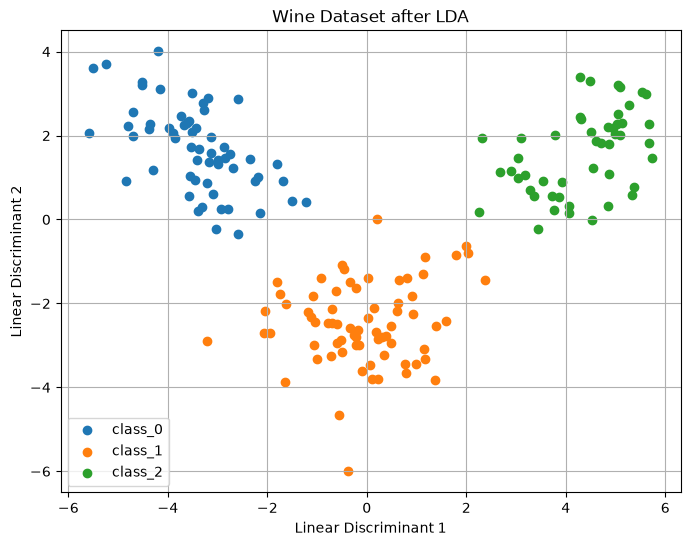

In [17]:
# Visualize the Wine dataset in the two-dimensional LDA space.
plt.figure(figsize=(8, 6))

for class_value, class_name in enumerate(wine.target_names):
    mask = y_wine == class_value
    plt.scatter(
        X_lda[mask, 0],
        X_lda[mask, 1],
        label=class_name
    )

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("Wine Dataset after LDA")
plt.legend()
plt.grid(True)
plt.show()


### PCA vs. LDA — Comparison

| Aspect | PCA | LDA |
|---|---|---|
| Type | Unsupervised | Supervised |
| Uses class labels? | No | Yes |
| Main objective | Maximize variance | Maximize class separability |
| Wine dimensions | 13 → 2 | 13 → 2 |
| Typical use | Compression and visualization | Classification-oriented dimensionality reduction |

For the Wine dataset, LDA can produce a representation with stronger class separation because it explicitly uses the class labels. PCA, on the other hand, preserves directions of maximum overall variance without considering the target classes. Therefore, PCA may preserve more general variation while LDA may be more useful when the primary goal is distinguishing known classes.

## Final Observations

1. **SVM:** Standardization and hyperparameter tuning are important for obtaining a reliable linear SVM classifier. The evaluation metrics and confusion matrix provide different views of classification performance.
2. **PCA:** The 13 original Wine features can be represented using fewer principal components while retaining a measurable proportion of the total variance. The cumulative variance determines how many components are required for a target such as 95%.
3. **PCA vs. LDA:** PCA is unsupervised and focuses on variance, whereas LDA is supervised and focuses on class separability. This makes LDA particularly useful when class labels are available and the goal is classification-oriented dimensionality reduction.